In [2]:
# =============================================================================
# 셀 1: 환경 / 경로 / 유틸리티 (regime_v4 재검증)
# =============================================================================
# 목적: SSOT 경로 정의, 공통 함수 로드
# 산출물: 없음 (환경 세팅)
# 주의: 다른 노트북과 변수명 일관성 유지
# =============================================================================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
import os

# -----------------------------------------------------------------------------
# 경로 설정 (SSOT)
# -----------------------------------------------------------------------------
load_dotenv()
QP2_ROOT = Path(os.getenv("QP2_ROOT", "C:/QP2"))

PATHS = {
    "data": QP2_ROOT / "data",
    "raw": QP2_ROOT / "data" / "raw",
    "interim": QP2_ROOT / "data" / "interim",
    "meta": QP2_ROOT / "data" / "meta",
}

# -----------------------------------------------------------------------------
# 유틸리티 함수
# -----------------------------------------------------------------------------
def winsorize(s: pd.Series, lower: float = 0.01, upper: float = 0.99) -> pd.Series:
    """극단값 제거 (percentile 기준)"""
    lo, hi = s.quantile([lower, upper])
    return s.clip(lo, hi)

def zscore_by_date(df: pd.DataFrame, col: str) -> pd.Series:
    """날짜별 cross-sectional z-score"""
    return df.groupby("date")[col].transform(lambda x: (x - x.mean()) / x.std())

# -----------------------------------------------------------------------------
# 핵심 파라미터
# -----------------------------------------------------------------------------
LAG_DAYS = 60          # filed → effective 지연 (기본값, 민감도 테스트 예정)
TOP_N = 30             # 포트폴리오 종목 수
VALUE_FILTER_PCT = 0.5 # Value 필터: B/M 상위 50%

# -----------------------------------------------------------------------------
# 확인 출력
# -----------------------------------------------------------------------------
print(f"QP2_ROOT: {QP2_ROOT}")
print(f"LAG_DAYS: {LAG_DAYS}, TOP_N: {TOP_N}, VALUE_FILTER: 상위 {int(VALUE_FILTER_PCT*100)}%")
print("셀 1 완료")

QP2_ROOT: C:\QP2
LAG_DAYS: 60, TOP_N: 30, VALUE_FILTER: 상위 50%
셀 1 완료


In [3]:
# =============================================================================
# 셀 2: 데이터 로드 + 시가총액 자동 생성
# =============================================================================
# 목적: 분기 재무, 주가, 수익률, 레짐, 시가총액 데이터 로드
# 산출물: fund_q, px_wide, px_m, ret_1m, mktcap_m, regime_m
# 주의: mktcap_monthly.parquet 없으면 자동 생성
# =============================================================================

import json
import gzip

# -----------------------------------------------------------------------------
# 분기 재무 데이터
# -----------------------------------------------------------------------------
fund_q = pd.read_parquet(PATHS["interim"] / "fundamentals_quarterly.parquet")

fund_q["filed"] = pd.to_datetime(fund_q["filed"])
fund_q["effective_date"] = fund_q["filed"] + pd.Timedelta(days=LAG_DAYS)

print(f"fund_q: {fund_q.shape[0]:,} rows, {fund_q['ticker_yahoo'].nunique()} tickers")
print(f"  기간: {fund_q['filed'].min().date()} ~ {fund_q['filed'].max().date()}")

# -----------------------------------------------------------------------------
# 주가 데이터 (wide → 월말 리샘플링)
# -----------------------------------------------------------------------------
px_wide = pd.read_parquet(PATHS["interim"] / "yahoo_adjclose_wide.parquet")

if "date" in px_wide.columns:
    px_wide = px_wide.set_index("date")
px_wide.index = pd.to_datetime(px_wide.index)

px_m = px_wide.resample("ME").last()
ret_1m = px_m.pct_change()

print(f"px_m: {px_m.shape[0]} months, {px_m.shape[1]} tickers")
print(f"  기간: {px_m.index.min().date()} ~ {px_m.index.max().date()}")

# -----------------------------------------------------------------------------
# 시가총액 데이터 (없으면 자동 생성)
# -----------------------------------------------------------------------------
mktcap_path = PATHS["interim"] / "mktcap_monthly.parquet"

if mktcap_path.exists():
    mktcap_m = pd.read_parquet(mktcap_path)
    if "date" in mktcap_m.columns:
        mktcap_m = mktcap_m.set_index("date")
    mktcap_m.index = pd.to_datetime(mktcap_m.index)
    print(f"mktcap_m: {mktcap_m.shape[0]} months, {mktcap_m.shape[1]} tickers (기존 파일 로드)")
else:
    print("⚠️ mktcap_monthly.parquet 없음 — 자동 생성 시작...")
    
    # -------------------------------------------------------------------------
    # Shares Outstanding 파싱 함수
    # -------------------------------------------------------------------------
    def parse_shares_outstanding(cik: int, sec_dir: Path) -> pd.DataFrame:
        """SEC companyfacts에서 CommonStockSharesOutstanding 추출"""
        
        fpath = sec_dir / f"{str(cik).zfill(10)}.json.gz"
        if not fpath.exists():
            return pd.DataFrame()
        
        with gzip.open(fpath, "rt", encoding="utf-8") as f:
            data = json.load(f)
        
        facts = data.get("facts", {}).get("us-gaap", {})
        
        candidates = [
            "CommonStockSharesOutstanding",
            "CommonStockSharesIssued",
            "WeightedAverageNumberOfSharesOutstandingBasic",
            "WeightedAverageNumberOfDilutedSharesOutstanding",
        ]
        
        rows = []
        for tag in candidates:
            if tag not in facts:
                continue
            units = facts[tag].get("units", {})
            for unit_key, entries in units.items():
                if unit_key != "shares":
                    continue
                for e in entries:
                    rows.append({
                        "cik": cik,
                        "end": e.get("end"),
                        "val": e.get("val"),
                        "tag": tag,
                    })
        
        if not rows:
            return pd.DataFrame()
        
        df = pd.DataFrame(rows)
        df["end"] = pd.to_datetime(df["end"], errors="coerce")
        df = df.dropna(subset=["end", "val"])
        df = df.sort_values(["end", "tag"]).drop_duplicates(subset=["end"], keep="first")
        
        return df[["cik", "end", "val"]]
    
    # -------------------------------------------------------------------------
    # 전체 종목 파싱
    # -------------------------------------------------------------------------
    sec_dir = PATHS["raw"] / "sec" / "companyfacts"
    master = pd.read_parquet(PATHS["meta"] / "sp500_universe.parquet")
    
    shares_list = []
    missing_ciks = []
    
    for _, row in master.iterrows():
        cik = row["cik"]
        ticker = row["ticker_yahoo"]
        
        df_shares = parse_shares_outstanding(cik, sec_dir)
        if df_shares.empty:
            missing_ciks.append(ticker)
            continue
        
        df_shares["ticker_yahoo"] = ticker
        shares_list.append(df_shares)
    
    print(f"  파싱 성공: {len(shares_list)} tickers, 실패: {len(missing_ciks)} tickers")
    
    if not shares_list:
        raise ValueError("❌ Shares Outstanding 데이터가 하나도 없음!")
    
    shares_all = pd.concat(shares_list, ignore_index=True)
    shares_all = shares_all.rename(columns={"end": "date", "val": "shares"})
    
    # 월말 기준 정렬
    shares_all["month"] = shares_all["date"].dt.to_period("M").dt.to_timestamp("M")
    shares_m = shares_all.groupby(["ticker_yahoo", "month"])["shares"].last().reset_index()
    shares_m = shares_m.rename(columns={"month": "date"})
    
    # wide format
    shares_wide = shares_m.pivot(index="date", columns="ticker_yahoo", values="shares")
    shares_wide.index = pd.to_datetime(shares_wide.index)
    
    # px_m 기간에 맞춰 reindex + forward fill
    shares_wide = shares_wide.reindex(px_m.index).ffill()
    
    # MarketCap = Price × Shares
    mktcap_m = px_m * shares_wide
    
    # 2009년 이후만
    mktcap_m = mktcap_m.loc["2009-01-01":]
    
    # 저장
    mktcap_m.to_parquet(mktcap_path)
    print(f"  저장 완료: {mktcap_path}")
    print(f"mktcap_m: {mktcap_m.shape[0]} months, {mktcap_m.shape[1]} tickers (새로 생성)")

# -----------------------------------------------------------------------------
# 레짐 데이터
# -----------------------------------------------------------------------------
regime_df = pd.read_parquet(PATHS["interim"] / "regime_v4.parquet")

if "date" in regime_df.columns:
    regime_df = regime_df.set_index("date")
regime_df.index = pd.to_datetime(regime_df.index)

regime_m = regime_df.resample("ME").last()

print(f"regime_m: {regime_m.shape[0]} months")
print(f"  레짐 종류 (regime): {regime_m['regime'].unique().tolist()}")

# -----------------------------------------------------------------------------
# 수익률 long format (이후 셀에서 사용)
# -----------------------------------------------------------------------------
ret_long = ret_1m.stack().reset_index()
ret_long.columns = ["date", "ticker_yahoo", "ret_1m"]

# -----------------------------------------------------------------------------
# 시가총액 long format (이후 셀에서 사용)
# -----------------------------------------------------------------------------
mktcap_long = mktcap_m.stack().reset_index()
mktcap_long.columns = ["date", "ticker_yahoo", "mktcap"]

# -----------------------------------------------------------------------------
# 공통 종목 확인
# -----------------------------------------------------------------------------
tickers_fund = set(fund_q["ticker_yahoo"].dropna().unique())
tickers_px = set(px_m.columns)
common_tickers = tickers_fund & tickers_px

print(f"\n공통 종목: {len(common_tickers)}")
print("셀 2 완료")

fund_q: 22,192 rows, 503 tickers
  기간: 2009-04-15 ~ 2026-01-23
px_m: 770 months, 503 tickers
  기간: 1962-01-31 ~ 2026-02-28
mktcap_m: 205 months, 503 tickers (기존 파일 로드)
regime_m: 765 months
  레짐 종류 (regime): ['Bear', 'Bull', 'Neutral']

공통 종목: 503
셀 2 완료


In [4]:
# 2009년 이후 NaN 비율 재확인
mktcap_2009 = mktcap_m.loc["2009-01-01":]
nan_pct_2009 = mktcap_2009.isna().sum().sum() / mktcap_2009.size * 100
print(f"2009년 이후 NaN 비율: {nan_pct_2009:.1f}%")

# 연도별 커버리지 확인
print("\n연도별 유효 데이터 비율:")
for year in [2009, 2012, 2015, 2018, 2021, 2024]:
    yearly = mktcap_m.loc[str(year)]
    valid_pct = (1 - yearly.isna().sum().sum() / yearly.size) * 100
    print(f"  {year}: {valid_pct:.1f}%")

2009년 이후 NaN 비율: 10.4%

연도별 유효 데이터 비율:
  2009: 69.1%
  2012: 82.7%
  2015: 87.5%
  2018: 92.3%
  2021: 96.6%
  2024: 99.1%


In [5]:
# =============================================================================
# 셀 3: Value 필터 (B/M 상위 50%) — 수정 v2
# =============================================================================
# 목적: Book-to-Market 계산 → 상위 50%만 "싼 놈" 후보로 선정
# 산출물: value_filter (date, ticker, bm, is_cheap)
# =============================================================================

# -----------------------------------------------------------------------------
# 분기 재무 → 월말 매핑 (effective_date 기준)
# -----------------------------------------------------------------------------
fund_val = fund_q[["ticker_yahoo", "effective_date", "StockholdersEquity"]].copy()
fund_val = fund_val.dropna(subset=["StockholdersEquity"])
fund_val = fund_val.rename(columns={"StockholdersEquity": "equity"})

fund_val["month"] = fund_val["effective_date"].dt.to_period("M").dt.to_timestamp("M")

fund_val = fund_val.sort_values("effective_date")
fund_val = fund_val.groupby(["ticker_yahoo", "month"]).last().reset_index()

print(f"fund_val (월별 Equity): {fund_val.shape[0]:,} rows, {fund_val['ticker_yahoo'].nunique()} tickers")

# -----------------------------------------------------------------------------
# MarketCap long format
# -----------------------------------------------------------------------------
mktcap_long = mktcap_m.stack().reset_index()
mktcap_long.columns = ["date", "ticker_yahoo", "mktcap"]

print(f"mktcap_long: {mktcap_long.shape[0]:,} rows")

# -----------------------------------------------------------------------------
# Equity + MarketCap 병합 → B/M 계산
# -----------------------------------------------------------------------------
fund_val = fund_val.rename(columns={"month": "date"})

value_df = pd.merge(
    mktcap_long,
    fund_val[["ticker_yahoo", "date", "equity"]],
    on=["ticker_yahoo", "date"],
    how="inner"
)

value_df["bm"] = value_df["equity"] / value_df["mktcap"]

value_df = value_df[value_df["equity"] > 0]
value_df = value_df[value_df["mktcap"] > 0]
value_df["bm"] = winsorize(value_df["bm"], 0.01, 0.99)

print(f"value_df (B/M 계산됨): {value_df.shape[0]:,} rows, {value_df['ticker_yahoo'].nunique()} tickers")

# -----------------------------------------------------------------------------
# 날짜별 B/M 상위 50% → is_cheap 플래그 (groupby 없이)
# -----------------------------------------------------------------------------
# 날짜별 percentile threshold 계산
thresholds = value_df.groupby("date")["bm"].quantile(1 - VALUE_FILTER_PCT).rename("threshold")

# 병합
value_filter = value_df.merge(thresholds, on="date")
value_filter["is_cheap"] = value_filter["bm"] >= value_filter["threshold"]

# 필요한 컬럼만
value_filter = value_filter[["date", "ticker_yahoo", "bm", "is_cheap"]]

# 확인
cheap_rate = value_filter["is_cheap"].mean() * 100
print(f"\nis_cheap 비율: {cheap_rate:.1f}% (목표: ~50%)")
print(f"기간: {value_filter['date'].min().date()} ~ {value_filter['date'].max().date()}")
print(f"value_filter: {value_filter.shape[0]:,} rows")
print("셀 3 완료")

fund_val (월별 Equity): 21,958 rows, 503 tickers
mktcap_long: 103,115 rows
value_df (B/M 계산됨): 20,769 rows, 498 tickers

is_cheap 비율: 50.3% (목표: ~50%)
기간: 2009-06-30 ~ 2026-01-31
value_filter: 20,769 rows
셀 3 완료


In [6]:
# =============================================================================
# 셀 4: Catalyst 스코어 (ΔROE, ΔLeverage, ΔCF)
# =============================================================================
# 목적: 재무 개선 신호 계산 — 싼 놈 중에서 "바뀌고 있는 놈" 선별
# 산출물: catalyst_df (date, ticker, delta_roe, delta_lev, delta_cf, catalyst_z)
# 주의: QoQ 변화 사용 (YoY는 계절성 문제 있음)
# =============================================================================

# -----------------------------------------------------------------------------
# 필요 지표 추출
# -----------------------------------------------------------------------------
fund_cat = fund_q[[
    "ticker_yahoo", "effective_date", "fy", "fp",
    "NetIncomeLoss", "StockholdersEquity", "Liabilities", "Assets", "CFO"
]].copy()

# NaN 처리 (일단 있는 데이터만)
print(f"fund_cat 원본: {fund_cat.shape[0]:,} rows")

# -----------------------------------------------------------------------------
# 지표 계산
# -----------------------------------------------------------------------------
# ROE = NetIncome / Equity
fund_cat["roe"] = fund_cat["NetIncomeLoss"] / fund_cat["StockholdersEquity"]

# Leverage = Liabilities / Assets (낮을수록 좋음)
fund_cat["leverage"] = fund_cat["Liabilities"] / fund_cat["Assets"]

# CF/Assets = CFO / Assets (현금흐름 효율)
fund_cat["cf_ratio"] = fund_cat["CFO"] / fund_cat["Assets"]

# 이상치 제거 (Equity <= 0 등)
fund_cat = fund_cat[fund_cat["StockholdersEquity"] > 0]
fund_cat = fund_cat[fund_cat["Assets"] > 0]

# 극단값 winsorize
for col in ["roe", "leverage", "cf_ratio"]:
    fund_cat[col] = winsorize(fund_cat[col], 0.01, 0.99)

print(f"fund_cat 필터 후: {fund_cat.shape[0]:,} rows, {fund_cat['ticker_yahoo'].nunique()} tickers")

# -----------------------------------------------------------------------------
# QoQ 변화 계산
# -----------------------------------------------------------------------------
fund_cat = fund_cat.sort_values(["ticker_yahoo", "effective_date"])

# 이전 분기 대비 변화
fund_cat["delta_roe"] = fund_cat.groupby("ticker_yahoo")["roe"].diff()
fund_cat["delta_lev"] = fund_cat.groupby("ticker_yahoo")["leverage"].diff()
fund_cat["delta_cf"] = fund_cat.groupby("ticker_yahoo")["cf_ratio"].diff()

# 부호 조정: leverage는 낮아지는 게 좋음 → 부호 반전
fund_cat["delta_lev"] = -fund_cat["delta_lev"]

# NaN 제거 (첫 분기는 diff 없음)
fund_cat = fund_cat.dropna(subset=["delta_roe", "delta_lev", "delta_cf"])

print(f"fund_cat (delta 계산): {fund_cat.shape[0]:,} rows")

# -----------------------------------------------------------------------------
# 월말 매핑
# -----------------------------------------------------------------------------
fund_cat["date"] = fund_cat["effective_date"].dt.to_period("M").dt.to_timestamp("M")

# 월별 마지막 분기 데이터
fund_cat = fund_cat.sort_values("effective_date")
catalyst_m = fund_cat.groupby(["ticker_yahoo", "date"]).last().reset_index()

print(f"catalyst_m (월별): {catalyst_m.shape[0]:,} rows")

# -----------------------------------------------------------------------------
# Cross-sectional Z-score (날짜별 표준화)
# -----------------------------------------------------------------------------
catalyst_df = catalyst_m[["date", "ticker_yahoo", "delta_roe", "delta_lev", "delta_cf"]].copy()

# 날짜별 z-score
for col in ["delta_roe", "delta_lev", "delta_cf"]:
    catalyst_df[f"{col}_z"] = zscore_by_date(catalyst_df, col)

# 종합 Catalyst 스코어 (동일 가중)
catalyst_df["catalyst_z"] = (
    catalyst_df["delta_roe_z"] + 
    catalyst_df["delta_lev_z"] + 
    catalyst_df["delta_cf_z"]
) / 3

# NaN 제거
catalyst_df = catalyst_df.dropna(subset=["catalyst_z"])

# 필요한 컬럼만
catalyst_df = catalyst_df[["date", "ticker_yahoo", "delta_roe_z", "delta_lev_z", "delta_cf_z", "catalyst_z"]]

print(f"\ncatalyst_df: {catalyst_df.shape[0]:,} rows, {catalyst_df['ticker_yahoo'].nunique()} tickers")
print(f"기간: {catalyst_df['date'].min().date()} ~ {catalyst_df['date'].max().date()}")
print(f"catalyst_z 분포:\n{catalyst_df['catalyst_z'].describe()}")
print("셀 4 완료")

fund_cat 원본: 22,192 rows
fund_cat 필터 후: 21,070 rows, 500 tickers
fund_cat (delta 계산): 19,472 rows
catalyst_m (월별): 19,427 rows

catalyst_df: 19,426 rows, 492 tickers
기간: 2009-09-30 ~ 2026-03-31
catalyst_z 분포:
count    1.942600e+04
mean    -7.315379e-19
std      6.011132e-01
min     -6.089605e+00
25%     -2.305147e-01
50%      2.153223e-02
75%      2.718734e-01
max      5.985284e+00
Name: catalyst_z, dtype: float64
셀 4 완료


In [7]:
# =============================================================================
# 셀 5: 최종 신호 (Value 필터 × Catalyst Top N)
# =============================================================================
# 목적: 싼 놈(is_cheap) 중에서 Catalyst 상위 N개 선정
# 산출물: signal_df (date, ticker, selected)
# 전략: Value(필터) + Catalyst(메인)
# =============================================================================

# -----------------------------------------------------------------------------
# Value 필터 + Catalyst 병합
# -----------------------------------------------------------------------------
signal_df = pd.merge(
    value_filter,
    catalyst_df[["date", "ticker_yahoo", "catalyst_z"]],
    on=["date", "ticker_yahoo"],
    how="inner"
)

print(f"signal_df (병합 후): {signal_df.shape[0]:,} rows, {signal_df['ticker_yahoo'].nunique()} tickers")

# -----------------------------------------------------------------------------
# Value 필터 적용: is_cheap = True인 놈만
# -----------------------------------------------------------------------------
signal_cheap = signal_df[signal_df["is_cheap"] == True].copy()

print(f"signal_cheap (싼 놈만): {signal_cheap.shape[0]:,} rows")

# -----------------------------------------------------------------------------
# 날짜별 Catalyst 상위 N개 선정
# -----------------------------------------------------------------------------
def select_top_n(group):
    """Catalyst 스코어 상위 N개 선정"""
    top = group.nlargest(TOP_N, "catalyst_z")
    top = top.copy()
    top["selected"] = True
    return top

selected = signal_cheap.groupby("date", group_keys=False).apply(select_top_n)

# 전체 signal_df에 selected 플래그 병합
signal_df["selected"] = False
signal_df.loc[selected.index, "selected"] = True

# 확인
n_dates = signal_df["date"].nunique()
n_selected_avg = signal_df[signal_df["selected"]]["date"].value_counts().mean()

print(f"\n날짜 수: {n_dates}")
print(f"날짜당 평균 선정 종목 수: {n_selected_avg:.1f} (목표: {TOP_N})")
print(f"기간: {signal_df['date'].min().date()} ~ {signal_df['date'].max().date()}")

# 최종 신호 테이블 (선정된 것만)
final_signal = signal_df[signal_df["selected"]][["date", "ticker_yahoo", "bm", "catalyst_z"]]
print(f"\nfinal_signal: {final_signal.shape[0]:,} rows")
print("셀 5 완료")

signal_df (병합 후): 19,216 rows, 490 tickers
signal_cheap (싼 놈만): 9,678 rows

날짜 수: 196
날짜당 평균 선정 종목 수: 20.4 (목표: 30)
기간: 2009-09-30 ~ 2026-01-31

final_signal: 4,001 rows
셀 5 완료


전략 수익률: 115 months
벤치마크 수익률: 115 months

성과 비교 (전체 기간)
A-3 Strategy    | CAGR:   17.1% | Sharpe:  1.00 | MaxDD:  -26.0%
EW Benchmark    | CAGR:   17.1% | Sharpe:  1.12 | MaxDD:  -23.6%


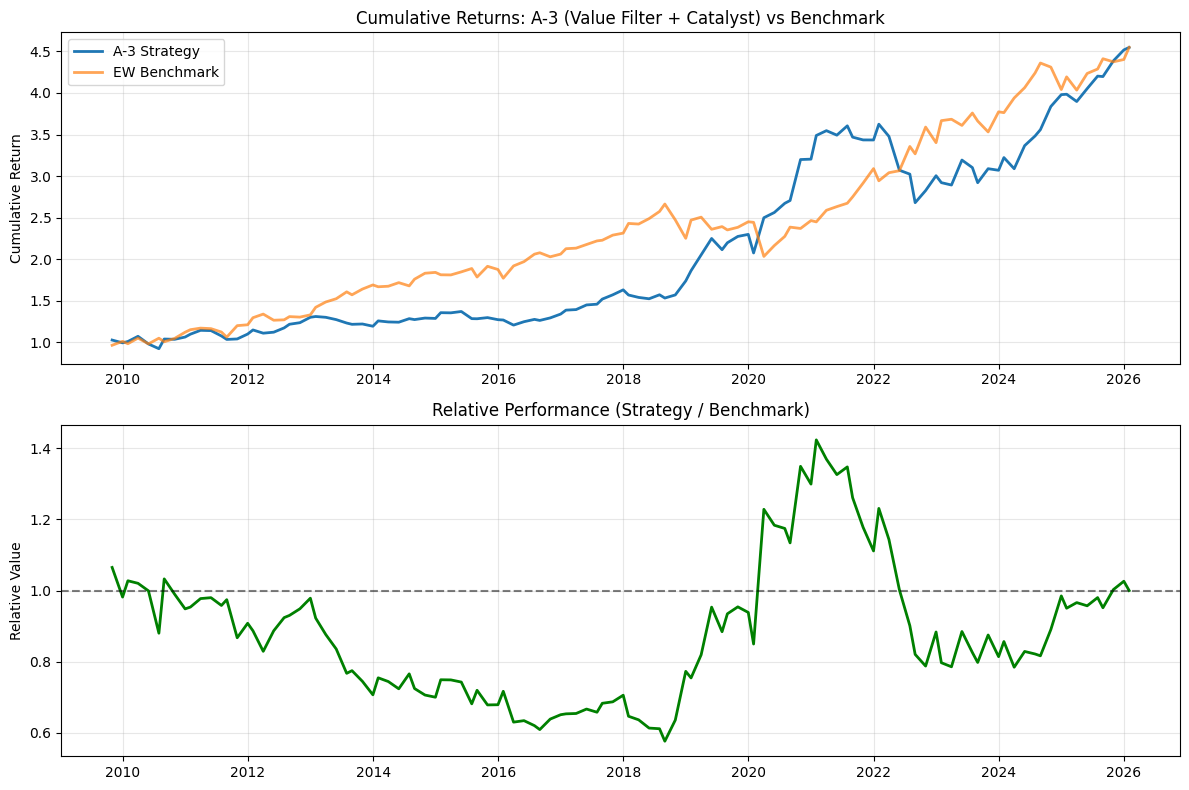

셀 6 완료


In [8]:
# =============================================================================
# 셀 6: 백테스트 (전체 기간)
# =============================================================================
# 목적: A-3 전략 (Value 필터 + Catalyst Top N) 성과 검증
# 비교: 전략 vs EW Benchmark (전 종목 동일가중)
# =============================================================================

import matplotlib.pyplot as plt

# -----------------------------------------------------------------------------
# 수익률 long format 준비
# -----------------------------------------------------------------------------
ret_long = ret_1m.stack().reset_index()
ret_long.columns = ["date", "ticker_yahoo", "ret_1m"]

# -----------------------------------------------------------------------------
# 포트폴리오 수익률 계산
# -----------------------------------------------------------------------------
signal_returns = signal_df[signal_df["selected"]][["date", "ticker_yahoo"]].copy()

# t월 신호 → t+1월 수익률
signal_returns["date_next"] = signal_returns["date"] + pd.DateOffset(months=1)

# t+1월 수익률 병합
signal_returns = signal_returns.merge(
    ret_long.rename(columns={"date": "date_next", "ret_1m": "ret_next"}),
    on=["date_next", "ticker_yahoo"],
    how="left"
)

# 날짜별 동일가중 평균 수익률
strat_ret = signal_returns.groupby("date")["ret_next"].mean()
strat_ret = strat_ret.dropna()

print(f"전략 수익률: {len(strat_ret)} months")

# -----------------------------------------------------------------------------
# Benchmark: 전 종목 동일가중
# -----------------------------------------------------------------------------
universe_tickers = signal_df["ticker_yahoo"].unique()
bm_ret = ret_1m[universe_tickers].mean(axis=1)
bm_ret = bm_ret.loc[strat_ret.index]

print(f"벤치마크 수익률: {len(bm_ret)} months")

# -----------------------------------------------------------------------------
# 누적 수익률
# -----------------------------------------------------------------------------
cum_strat = (1 + strat_ret).cumprod()
cum_bm = (1 + bm_ret).cumprod()

# -----------------------------------------------------------------------------
# 성과 지표
# -----------------------------------------------------------------------------
def calc_metrics(ret_series, name=""):
    """CAGR, Sharpe, MaxDD 계산"""
    n_years = len(ret_series) / 12
    total_ret = (1 + ret_series).prod() - 1
    cagr = (1 + total_ret) ** (1 / n_years) - 1
    sharpe = ret_series.mean() / ret_series.std() * np.sqrt(12)
    
    cum = (1 + ret_series).cumprod()
    rolling_max = cum.cummax()
    drawdown = (cum - rolling_max) / rolling_max
    max_dd = drawdown.min()
    
    return {
        "name": name,
        "CAGR": f"{cagr:.1%}",
        "Sharpe": f"{sharpe:.2f}",
        "MaxDD": f"{max_dd:.1%}",
        "총수익률": f"{total_ret:.1%}"
    }

metrics_strat = calc_metrics(strat_ret, "A-3 Strategy")
metrics_bm = calc_metrics(bm_ret, "EW Benchmark")

print("\n" + "="*50)
print("성과 비교 (전체 기간)")
print("="*50)
for m in [metrics_strat, metrics_bm]:
    print(f"{m['name']:15} | CAGR: {m['CAGR']:>7} | Sharpe: {m['Sharpe']:>5} | MaxDD: {m['MaxDD']:>7}")

# -----------------------------------------------------------------------------
# 시각화
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# 누적 수익률
axes[0].plot(cum_strat.index, cum_strat.values, label="A-3 Strategy", linewidth=2)
axes[0].plot(cum_bm.index, cum_bm.values, label="EW Benchmark", linewidth=2, alpha=0.7)
axes[0].set_title("Cumulative Returns: A-3 (Value Filter + Catalyst) vs Benchmark")
axes[0].set_ylabel("Cumulative Return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 상대 성과 (Strategy / Benchmark)
relative = cum_strat / cum_bm
axes[1].plot(relative.index, relative.values, color="green", linewidth=2)
axes[1].axhline(1, color="black", linestyle="--", alpha=0.5)
axes[1].set_title("Relative Performance (Strategy / Benchmark)")
axes[1].set_ylabel("Relative Value")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("셀 6 완료")

레짐별 분석 대상: 115 months
레짐 분포:
regime
Bear       15
Bull       89
Neutral    11
Name: count, dtype: int64

레짐별 성과 비교 (A-3 Strategy vs EW Benchmark) — regime_v4
레짐         |    월수 |       전략 |       BM |       초과 |  t-stat |   승패
-------------------------------------------------------------------------------------
Bull       |    89 |   15.2% |   27.2% |  -11.9% |   -1.75 |    ❌
Neutral    |    11 |   29.5% |   28.9% |    0.6% |    0.02 |    ✅
Bear       |    15 |   21.3% |  -51.3% |   72.6% |    1.83 |    ✅

Bear 내부 세분화 (A-3)
  declining   : n= 14  excess_ann=+87.3%  t=2.21
  recovering: n=1 (표본 부족)


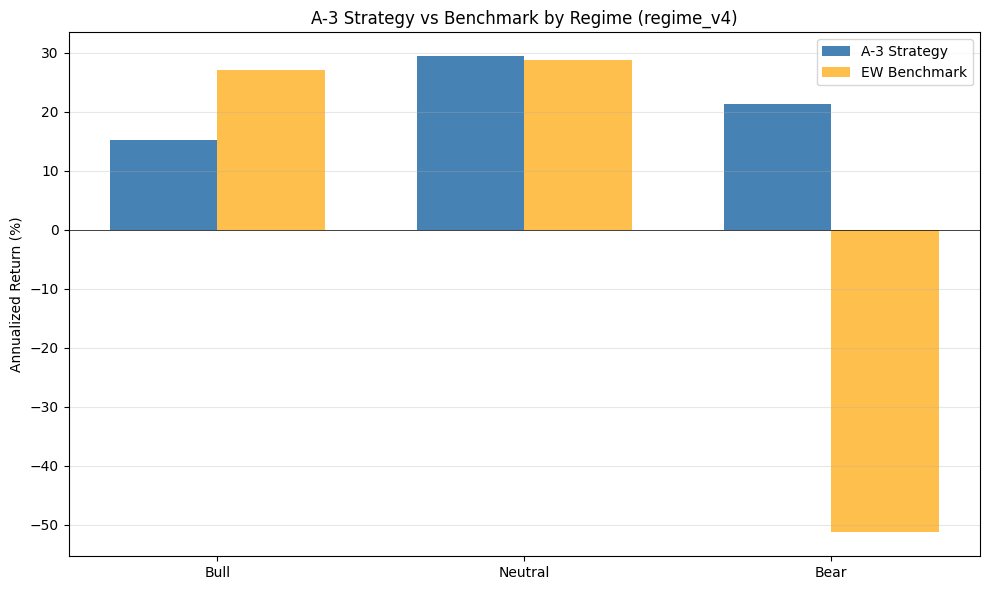

셀 7 완료


In [9]:
# =============================================================================
# 셀 7: 레짐별 백테스트 (regime_v4)
# =============================================================================
# 목적: A-3 전략이 새 3-Regime에서 유효한지 검증
# 사용: regime_v4 (3레짐: Bull / Neutral / Bear)
# 변경: regime_v2(7레짐) → regime_v4(3레짐) + Bear 내부 세분화
# =============================================================================

# -----------------------------------------------------------------------------
# 레짐 데이터 병합
# -----------------------------------------------------------------------------
strat_with_regime = strat_ret.reset_index()
strat_with_regime.columns = ["date", "strat_ret"]

# regime_v4 merge
strat_with_regime = strat_with_regime.merge(
    regime_m[["regime", "bear_phase"]].reset_index().rename(columns={"index": "date"}),
    on="date",
    how="left"
)

# bm_ret도 붙이기
strat_with_regime["bm_ret"] = bm_ret.values

# NaN 레짐 제거
strat_with_regime = strat_with_regime.dropna(subset=["regime"])

print(f"레짐별 분석 대상: {len(strat_with_regime)} months")
print(f"레짐 분포:\n{strat_with_regime['regime'].value_counts().sort_index()}")

# -----------------------------------------------------------------------------
# 레짐별 성과 계산 함수
# -----------------------------------------------------------------------------
def calc_regime_metrics(df, regime_col, regime_val):
    """레짐별 성과 지표"""
    sub = df[df[regime_col] == regime_val]
    if len(sub) < 6:
        return None
    
    n_months = len(sub)
    strat_ann = sub["strat_ret"].mean() * 12
    strat_sharpe = sub["strat_ret"].mean() / sub["strat_ret"].std() * np.sqrt(12) if sub["strat_ret"].std() > 0 else 0
    bm_ann = sub["bm_ret"].mean() * 12
    bm_sharpe = sub["bm_ret"].mean() / sub["bm_ret"].std() * np.sqrt(12) if sub["bm_ret"].std() > 0 else 0
    excess_ret = sub["strat_ret"] - sub["bm_ret"]
    excess_ann = excess_ret.mean() * 12
    
    # t-stat
    t_stat = excess_ret.mean() / (excess_ret.std() / np.sqrt(len(excess_ret))) if excess_ret.std() > 0 else 0
    
    return {
        "regime": regime_val,
        "months": n_months,
        "strat_ann": strat_ann,
        "strat_sharpe": strat_sharpe,
        "bm_ann": bm_ann,
        "bm_sharpe": bm_sharpe,
        "excess_ann": excess_ann,
        "t_stat": t_stat,
        "win": "✅" if excess_ann > 0 else "❌"
    }

# -----------------------------------------------------------------------------
# 3레짐 성과
# -----------------------------------------------------------------------------
print("\n" + "="*85)
print("레짐별 성과 비교 (A-3 Strategy vs EW Benchmark) — regime_v4")
print("="*85)

results = []
for regime in ["Bull", "Neutral", "Bear"]:
    m = calc_regime_metrics(strat_with_regime, "regime", regime)
    if m:
        results.append(m)

results_df = pd.DataFrame(results)

print(f"{'레짐':<10} | {'월수':>5} | {'전략':>8} | {'BM':>8} | {'초과':>8} | {'t-stat':>7} | {'승패':>4}")
print("-"*85)
for _, row in results_df.iterrows():
    print(f"{row['regime']:<10} | {row['months']:>5} | {row['strat_ann']:>7.1%} | "
          f"{row['bm_ann']:>7.1%} | {row['excess_ann']:>7.1%} | {row['t_stat']:>7.2f} | {row['win']:>4}")

# -----------------------------------------------------------------------------
# Bear 내부 세분화 (declining vs recovering)
# -----------------------------------------------------------------------------
print("\n" + "="*85)
print("Bear 내부 세분화 (A-3)")
print("="*85)

bear_data = strat_with_regime[strat_with_regime["regime"] == "Bear"].copy()
for phase in ["declining", "recovering"]:
    sub = bear_data[bear_data["bear_phase"] == phase]
    if len(sub) < 3:
        print(f"  {phase}: n={len(sub)} (표본 부족)")
        continue
    excess = sub["strat_ret"] - sub["bm_ret"]
    t = excess.mean() / (excess.std() / np.sqrt(len(excess))) if excess.std() > 0 else 0
    print(f"  {phase:12s}: n={len(sub):3d}  excess_ann={excess.mean()*12:+.1%}  t={t:.2f}")

# -----------------------------------------------------------------------------
# 시각화
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(results_df))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], results_df["strat_ann"] * 100, width, 
               label="A-3 Strategy", color="steelblue")
bars2 = ax.bar([i + width/2 for i in x], results_df["bm_ann"] * 100, width, 
               label="EW Benchmark", color="orange", alpha=0.7)

ax.set_ylabel("Annualized Return (%)")
ax.set_title("A-3 Strategy vs Benchmark by Regime (regime_v4)")
ax.set_xticks(x)
ax.set_xticklabels(results_df["regime"])
ax.legend()
ax.axhline(0, color="black", linestyle="-", linewidth=0.5)
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.show()

print("셀 7 완료")


LAG 민감도 테스트 중...
  LAG=0일 테스트 중...
  LAG=30일 테스트 중...
  LAG=45일 테스트 중...
  LAG=60일 테스트 중...
  LAG=90일 테스트 중...

LAG 민감도 테스트 결과
   LAG |     CAGR |  Sharpe |    MaxDD |     초과수익 |    월수
----------------------------------------------------------------------
   0.0일 |   11.7% |    0.75 |  -31.4% |   -5.9% |   117
  30.0일 |   16.5% |    1.08 |  -35.1% |   -1.5% |   115
  45.0일 |   20.9% |    1.15 |  -36.0% |    3.1% |   114
  60.0일 |   17.1% |    1.00 |  -26.0% |    0.2% |   115
  90.0일 |   11.9% |    0.77 |  -30.5% |   -4.1% |   114
----------------------------------------------------------------------
Sharpe 기준 최적 LAG: 45일


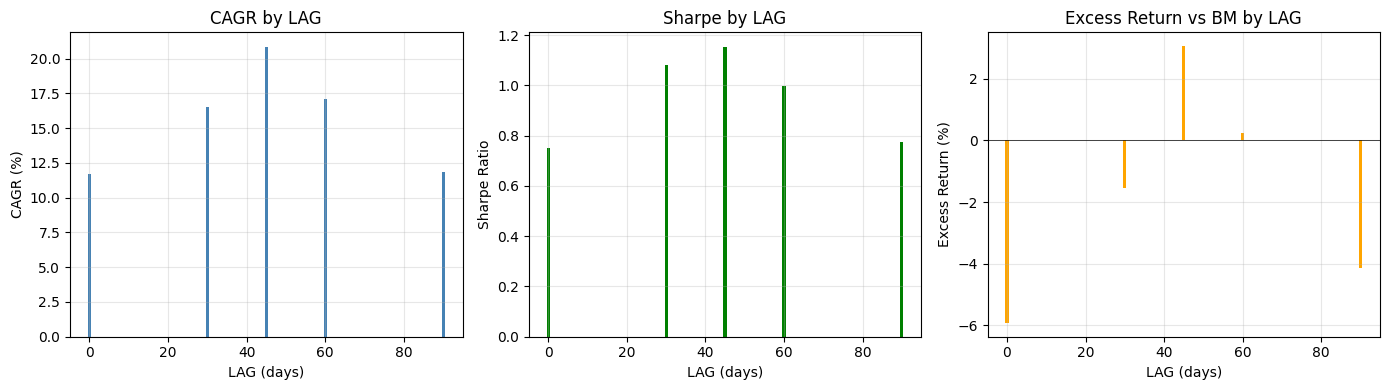

셀 8 완료


In [10]:
# =============================================================================
# 셀 8: LAG 민감도 테스트
# =============================================================================
# 목적: filed → effective 지연 일수가 성과에 미치는 영향 확인
# 테스트: LAG = 0, 30, 45, 60, 90일
# =============================================================================

LAG_OPTIONS = [0, 30, 45, 60, 90]

# BM 수익률 전체 (나중에 공통 인덱스로 맞춤)
universe_tickers = signal_df["ticker_yahoo"].unique()
bm_ret_full = ret_1m[universe_tickers].mean(axis=1)

def run_backtest_with_lag(lag_days):
    """특정 LAG로 전체 파이프라인 재실행 후 성과 반환"""
    
    # 1) effective_date 재계산
    fund_temp = fund_q.copy()
    fund_temp["effective_date"] = fund_temp["filed"] + pd.Timedelta(days=lag_days)
    
    # 2) Value 필터 재계산
    fund_val_temp = fund_temp[["ticker_yahoo", "effective_date", "StockholdersEquity"]].copy()
    fund_val_temp = fund_val_temp.dropna(subset=["StockholdersEquity"])
    fund_val_temp = fund_val_temp.rename(columns={"StockholdersEquity": "equity"})
    fund_val_temp["month"] = fund_val_temp["effective_date"].dt.to_period("M").dt.to_timestamp("M")
    fund_val_temp = fund_val_temp.sort_values("effective_date")
    fund_val_temp = fund_val_temp.groupby(["ticker_yahoo", "month"]).last().reset_index()
    fund_val_temp = fund_val_temp.rename(columns={"month": "date"})
    
    value_temp = pd.merge(
        mktcap_long,
        fund_val_temp[["ticker_yahoo", "date", "equity"]],
        on=["ticker_yahoo", "date"],
        how="inner"
    )
    value_temp["bm"] = value_temp["equity"] / value_temp["mktcap"]
    value_temp = value_temp[(value_temp["equity"] > 0) & (value_temp["mktcap"] > 0)]
    value_temp["bm"] = winsorize(value_temp["bm"], 0.01, 0.99)
    
    thresholds = value_temp.groupby("date")["bm"].quantile(0.5).rename("threshold")
    value_temp = value_temp.merge(thresholds, on="date")
    value_temp["is_cheap"] = value_temp["bm"] >= value_temp["threshold"]
    
    # 3) Catalyst 재계산
    fund_cat_temp = fund_temp[[
        "ticker_yahoo", "effective_date", 
        "NetIncomeLoss", "StockholdersEquity", "Liabilities", "Assets", "CFO"
    ]].copy()
    
    fund_cat_temp["roe"] = fund_cat_temp["NetIncomeLoss"] / fund_cat_temp["StockholdersEquity"]
    fund_cat_temp["leverage"] = fund_cat_temp["Liabilities"] / fund_cat_temp["Assets"]
    fund_cat_temp["cf_ratio"] = fund_cat_temp["CFO"] / fund_cat_temp["Assets"]
    
    fund_cat_temp = fund_cat_temp[(fund_cat_temp["StockholdersEquity"] > 0) & (fund_cat_temp["Assets"] > 0)]
    
    for col in ["roe", "leverage", "cf_ratio"]:
        fund_cat_temp[col] = winsorize(fund_cat_temp[col], 0.01, 0.99)
    
    fund_cat_temp = fund_cat_temp.sort_values(["ticker_yahoo", "effective_date"])
    fund_cat_temp["delta_roe"] = fund_cat_temp.groupby("ticker_yahoo")["roe"].diff()
    fund_cat_temp["delta_lev"] = -fund_cat_temp.groupby("ticker_yahoo")["leverage"].diff()
    fund_cat_temp["delta_cf"] = fund_cat_temp.groupby("ticker_yahoo")["cf_ratio"].diff()
    fund_cat_temp = fund_cat_temp.dropna(subset=["delta_roe", "delta_lev", "delta_cf"])
    
    fund_cat_temp["date"] = fund_cat_temp["effective_date"].dt.to_period("M").dt.to_timestamp("M")
    fund_cat_temp = fund_cat_temp.sort_values("effective_date")
    cat_temp = fund_cat_temp.groupby(["ticker_yahoo", "date"]).last().reset_index()
    
    cat_temp = cat_temp[["date", "ticker_yahoo", "delta_roe", "delta_lev", "delta_cf"]].copy()
    for col in ["delta_roe", "delta_lev", "delta_cf"]:
        cat_temp[f"{col}_z"] = zscore_by_date(cat_temp, col)
    cat_temp["catalyst_z"] = (cat_temp["delta_roe_z"] + cat_temp["delta_lev_z"] + cat_temp["delta_cf_z"]) / 3
    cat_temp = cat_temp.dropna(subset=["catalyst_z"])
    
    # 4) 신호 생성
    signal_temp = pd.merge(
        value_temp[["date", "ticker_yahoo", "bm", "is_cheap"]],
        cat_temp[["date", "ticker_yahoo", "catalyst_z"]],
        on=["date", "ticker_yahoo"],
        how="inner"
    )
    
    signal_cheap_temp = signal_temp[signal_temp["is_cheap"]].copy()
    
    # Top N 선정
    signal_cheap_temp["rank"] = signal_cheap_temp.groupby("date")["catalyst_z"].rank(ascending=False)
    selected_temp = signal_cheap_temp[signal_cheap_temp["rank"] <= TOP_N].copy()
    
    # 5) 수익률 계산
    selected_temp["date_next"] = selected_temp["date"] + pd.DateOffset(months=1)
    selected_temp = selected_temp.merge(
        ret_long.rename(columns={"date": "date_next", "ret_1m": "ret_next"}),
        on=["date_next", "ticker_yahoo"],
        how="left"
    )
    
    strat_ret_temp = selected_temp.groupby("date")["ret_next"].mean().dropna()
    
    if len(strat_ret_temp) < 12:
        return None
    
    # 6) 성과 계산
    n_years = len(strat_ret_temp) / 12
    total_ret = (1 + strat_ret_temp).prod() - 1
    cagr = (1 + total_ret) ** (1 / n_years) - 1
    sharpe = strat_ret_temp.mean() / strat_ret_temp.std() * np.sqrt(12)
    
    cum = (1 + strat_ret_temp).cumprod()
    max_dd = ((cum - cum.cummax()) / cum.cummax()).min()
    
    # BM 대비 초과 성과 — 공통 인덱스만
    common_idx = strat_ret_temp.index.intersection(bm_ret_full.index)
    if len(common_idx) < 12:
        return None
    excess = (strat_ret_temp.loc[common_idx] - bm_ret_full.loc[common_idx]).mean() * 12
    
    return {
        "lag": lag_days,
        "cagr": cagr,
        "sharpe": sharpe,
        "max_dd": max_dd,
        "excess_ann": excess,
        "n_months": len(strat_ret_temp)
    }

# -----------------------------------------------------------------------------
# LAG별 테스트 실행
# -----------------------------------------------------------------------------
print("LAG 민감도 테스트 중...")
lag_results = []

for lag in LAG_OPTIONS:
    print(f"  LAG={lag}일 테스트 중...")
    result = run_backtest_with_lag(lag)
    if result:
        lag_results.append(result)

lag_df = pd.DataFrame(lag_results)

# -----------------------------------------------------------------------------
# 결과 출력
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("LAG 민감도 테스트 결과")
print("="*70)
print(f"{'LAG':>6} | {'CAGR':>8} | {'Sharpe':>7} | {'MaxDD':>8} | {'초과수익':>8} | {'월수':>5}")
print("-"*70)

for _, row in lag_df.iterrows():
    print(f"{row['lag']:>6}일 | {row['cagr']:>7.1%} | {row['sharpe']:>7.2f} | {row['max_dd']:>7.1%} | {row['excess_ann']:>7.1%} | {row['n_months']:>5.0f}")

# 최적 LAG
best_idx = lag_df["sharpe"].idxmax()
best_lag = lag_df.loc[best_idx, "lag"]
print("-"*70)
print(f"Sharpe 기준 최적 LAG: {best_lag}일")

# -----------------------------------------------------------------------------
# 시각화
# -----------------------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].bar(lag_df["lag"], lag_df["cagr"] * 100, color="steelblue")
axes[0].set_xlabel("LAG (days)")
axes[0].set_ylabel("CAGR (%)")
axes[0].set_title("CAGR by LAG")
axes[0].grid(True, alpha=0.3)

axes[1].bar(lag_df["lag"], lag_df["sharpe"], color="green")
axes[1].set_xlabel("LAG (days)")
axes[1].set_ylabel("Sharpe Ratio")
axes[1].set_title("Sharpe by LAG")
axes[1].grid(True, alpha=0.3)

axes[2].bar(lag_df["lag"], lag_df["excess_ann"] * 100, color="orange")
axes[2].set_xlabel("LAG (days)")
axes[2].set_ylabel("Excess Return (%)")
axes[2].set_title("Excess Return vs BM by LAG")
axes[2].axhline(0, color="black", linestyle="-", linewidth=0.5)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("셀 8 완료")

레짐별 LAG 민감도 테스트 중... (regime_v4)

  Bull 테스트 중...
    LAG=0일: Sharpe=0.84, 초과=-16.4%
    LAG=30일: Sharpe=1.37, 초과=-11.6%
    LAG=45일: Sharpe=1.33, 초과=-9.3%
    LAG=60일: Sharpe=1.04, 초과=-12.0%
    LAG=90일: Sharpe=0.86, 초과=-14.3%

  Neutral 테스트 중...
    LAG=0일: Sharpe=0.89, 초과=-14.1%
    LAG=30일: Sharpe=0.91, 초과=-13.6%
    LAG=45일: Sharpe=1.38, 초과=-2.9%
    LAG=60일: Sharpe=1.93, 초과=0.6%
    LAG=90일: Sharpe=1.73, 초과=-2.9%

  Bear 테스트 중...
    LAG=0일: Sharpe=0.46, 초과=63.4%
    LAG=30일: Sharpe=0.57, 초과=66.9%
    LAG=45일: Sharpe=0.86, 초과=79.8%
    LAG=60일: Sharpe=0.69, 초과=72.6%
    LAG=90일: Sharpe=0.13, 초과=54.5%

  Bear(declining) 테스트 중...
    LAG=0일: Sharpe=0.56, 초과=78.4%
    LAG=30일: Sharpe=0.72, 초과=83.2%
    LAG=45일: Sharpe=1.07, 초과=98.9%
    LAG=60일: Sharpe=0.76, 초과=87.3%
    LAG=90일: Sharpe=0.17, 초과=67.6%

  Bear(recovering) 테스트 중...

레짐별 최적 LAG (Sharpe 기준) — regime_v4
Bull                   | 최적 LAG:  30일 | Sharpe: 1.37 | 초과: -11.6%
Neutral                | 최적 LAG:  60일 | Sharpe: 1.93 

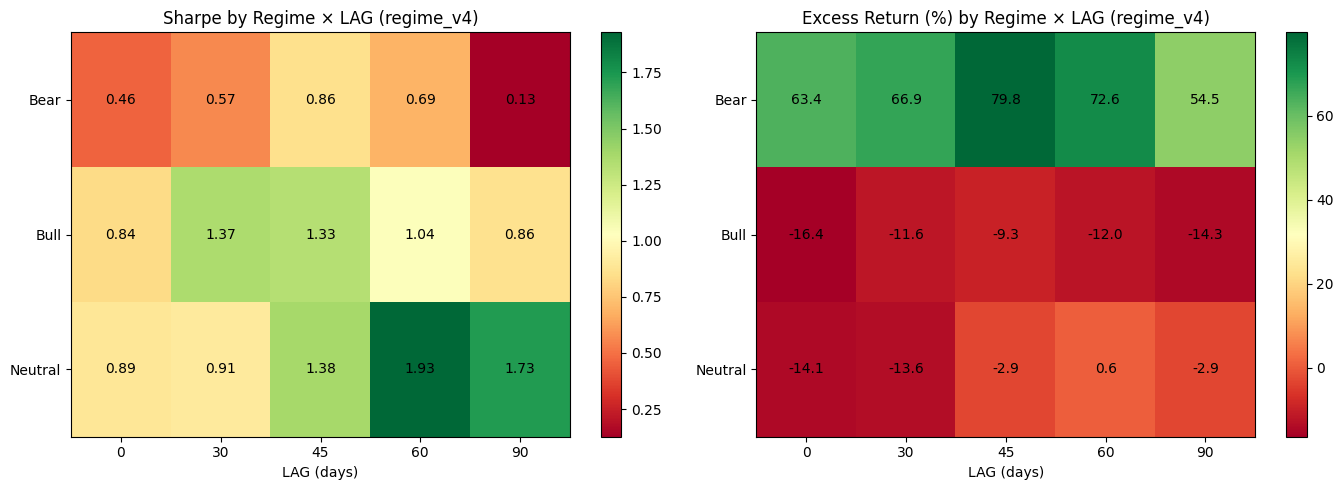


셀 9 완료


In [11]:
# =============================================================================
# 셀 9: 레짐별 LAG 민감도 테스트 (regime_v4)
# =============================================================================
# 목적: 새 3-Regime에서 레짐마다 최적 LAG 확인
# 변경: regime_v2 → regime_v4 (Bull/Neutral/Bear + bear_phase)
# =============================================================================

LAG_OPTIONS = [0, 30, 45, 60, 90]
TARGET_REGIMES = ["Bull", "Neutral", "Bear"]

def run_backtest_by_regime_lag(lag_days, target_regime, bear_phase_filter=None):
    """특정 LAG + 특정 레짐에서의 성과 반환
    
    bear_phase_filter: None(전체), "declining", "recovering"
    """
    
    # 1) effective_date 재계산
    fund_temp = fund_q.copy()
    fund_temp["effective_date"] = fund_temp["filed"] + pd.Timedelta(days=lag_days)
    
    # 2) Value 필터
    fund_val_temp = fund_temp[["ticker_yahoo", "effective_date", "StockholdersEquity"]].copy()
    fund_val_temp = fund_val_temp.dropna(subset=["StockholdersEquity"])
    fund_val_temp = fund_val_temp.rename(columns={"StockholdersEquity": "equity"})
    fund_val_temp["month"] = fund_val_temp["effective_date"].dt.to_period("M").dt.to_timestamp("M")
    fund_val_temp = fund_val_temp.sort_values("effective_date")
    fund_val_temp = fund_val_temp.groupby(["ticker_yahoo", "month"]).last().reset_index()
    fund_val_temp = fund_val_temp.rename(columns={"month": "date"})
    
    value_temp = pd.merge(
        mktcap_long,
        fund_val_temp[["ticker_yahoo", "date", "equity"]],
        on=["ticker_yahoo", "date"],
        how="inner"
    )
    value_temp["bm"] = value_temp["equity"] / value_temp["mktcap"]
    value_temp = value_temp[(value_temp["equity"] > 0) & (value_temp["mktcap"] > 0)]
    value_temp["bm"] = winsorize(value_temp["bm"], 0.01, 0.99)
    
    thresholds = value_temp.groupby("date")["bm"].quantile(0.5).rename("threshold")
    value_temp = value_temp.merge(thresholds, on="date")
    value_temp["is_cheap"] = value_temp["bm"] >= value_temp["threshold"]
    
    # 3) Catalyst
    fund_cat_temp = fund_temp[[
        "ticker_yahoo", "effective_date", 
        "NetIncomeLoss", "StockholdersEquity", "Liabilities", "Assets", "CFO"
    ]].copy()
    
    fund_cat_temp["roe"] = fund_cat_temp["NetIncomeLoss"] / fund_cat_temp["StockholdersEquity"]
    fund_cat_temp["leverage"] = fund_cat_temp["Liabilities"] / fund_cat_temp["Assets"]
    fund_cat_temp["cf_ratio"] = fund_cat_temp["CFO"] / fund_cat_temp["Assets"]
    
    fund_cat_temp = fund_cat_temp[(fund_cat_temp["StockholdersEquity"] > 0) & (fund_cat_temp["Assets"] > 0)]
    
    for col in ["roe", "leverage", "cf_ratio"]:
        fund_cat_temp[col] = winsorize(fund_cat_temp[col], 0.01, 0.99)
    
    fund_cat_temp = fund_cat_temp.sort_values(["ticker_yahoo", "effective_date"])
    fund_cat_temp["delta_roe"] = fund_cat_temp.groupby("ticker_yahoo")["roe"].diff()
    fund_cat_temp["delta_lev"] = -fund_cat_temp.groupby("ticker_yahoo")["leverage"].diff()
    fund_cat_temp["delta_cf"] = fund_cat_temp.groupby("ticker_yahoo")["cf_ratio"].diff()
    fund_cat_temp = fund_cat_temp.dropna(subset=["delta_roe", "delta_lev", "delta_cf"])
    
    fund_cat_temp["date"] = fund_cat_temp["effective_date"].dt.to_period("M").dt.to_timestamp("M")
    fund_cat_temp = fund_cat_temp.sort_values("effective_date")
    cat_temp = fund_cat_temp.groupby(["ticker_yahoo", "date"]).last().reset_index()
    
    cat_temp = cat_temp[["date", "ticker_yahoo", "delta_roe", "delta_lev", "delta_cf"]].copy()
    for col in ["delta_roe", "delta_lev", "delta_cf"]:
        cat_temp[f"{col}_z"] = zscore_by_date(cat_temp, col)
    cat_temp["catalyst_z"] = (cat_temp["delta_roe_z"] + cat_temp["delta_lev_z"] + cat_temp["delta_cf_z"]) / 3
    cat_temp = cat_temp.dropna(subset=["catalyst_z"])
    
    # 4) 신호 생성
    signal_temp = pd.merge(
        value_temp[["date", "ticker_yahoo", "bm", "is_cheap"]],
        cat_temp[["date", "ticker_yahoo", "catalyst_z"]],
        on=["date", "ticker_yahoo"],
        how="inner"
    )
    
    signal_cheap_temp = signal_temp[signal_temp["is_cheap"]].copy()
    signal_cheap_temp["rank"] = signal_cheap_temp.groupby("date")["catalyst_z"].rank(ascending=False)
    selected_temp = signal_cheap_temp[signal_cheap_temp["rank"] <= TOP_N].copy()
    
    # 5) 수익률 계산
    selected_temp["date_next"] = selected_temp["date"] + pd.DateOffset(months=1)
    selected_temp = selected_temp.merge(
        ret_long.rename(columns={"date": "date_next", "ret_1m": "ret_next"}),
        on=["date_next", "ticker_yahoo"],
        how="left"
    )
    
    # 레짐 필터링 (regime_v4)
    selected_temp = selected_temp.merge(
        regime_m[["regime", "bear_phase"]].reset_index().rename(columns={"index": "date"}),
        on="date",
        how="left"
    )
    
    # 레짐 필터
    regime_mask = selected_temp["regime"] == target_regime
    if bear_phase_filter is not None:
        regime_mask = regime_mask & (selected_temp["bear_phase"] == bear_phase_filter)
    
    selected_regime = selected_temp[regime_mask]
    
    if len(selected_regime) < 30:
        return None
    
    strat_ret_temp = selected_regime.groupby("date")["ret_next"].mean().dropna()
    
    if len(strat_ret_temp) < 6:
        return None
    
    # 6) 성과 계산
    ann_ret = strat_ret_temp.mean() * 12
    sharpe = strat_ret_temp.mean() / strat_ret_temp.std() * np.sqrt(12) if strat_ret_temp.std() > 0 else 0
    
    # BM 대비
    common_idx = strat_ret_temp.index.intersection(bm_ret_full.index)
    if len(common_idx) < 6:
        return None
    excess = (strat_ret_temp.loc[common_idx] - bm_ret_full.loc[common_idx]).mean() * 12
    
    return {
        "regime": target_regime + (f"({bear_phase_filter})" if bear_phase_filter else ""),
        "lag": lag_days,
        "ann_ret": ann_ret,
        "sharpe": sharpe,
        "excess": excess,
        "n_months": len(strat_ret_temp)
    }

# -----------------------------------------------------------------------------
# 3레짐 × LAG 전체 테스트
# -----------------------------------------------------------------------------
print("레짐별 LAG 민감도 테스트 중... (regime_v4)")
results = []

for regime in TARGET_REGIMES:
    print(f"\n  {regime} 테스트 중...")
    for lag in LAG_OPTIONS:
        result = run_backtest_by_regime_lag(lag, regime)
        if result:
            results.append(result)
            print(f"    LAG={lag}일: Sharpe={result['sharpe']:.2f}, 초과={result['excess']:.1%}")

# Bear 내부 세분화
print(f"\n  Bear(declining) 테스트 중...")
for lag in LAG_OPTIONS:
    result = run_backtest_by_regime_lag(lag, "Bear", bear_phase_filter="declining")
    if result:
        results.append(result)
        print(f"    LAG={lag}일: Sharpe={result['sharpe']:.2f}, 초과={result['excess']:.1%}")

print(f"\n  Bear(recovering) 테스트 중...")
for lag in LAG_OPTIONS:
    result = run_backtest_by_regime_lag(lag, "Bear", bear_phase_filter="recovering")
    if result:
        results.append(result)
        print(f"    LAG={lag}일: Sharpe={result['sharpe']:.2f}, 초과={result['excess']:.1%}")

results_df = pd.DataFrame(results)

# -----------------------------------------------------------------------------
# 레짐별 최적 LAG 찾기
# -----------------------------------------------------------------------------
print("\n" + "="*70)
print("레짐별 최적 LAG (Sharpe 기준) — regime_v4")
print("="*70)

all_regime_labels = ["Bull", "Neutral", "Bear", "Bear(declining)", "Bear(recovering)"]
for regime in all_regime_labels:
    sub = results_df[results_df["regime"] == regime]
    if sub.empty:
        print(f"{regime:<22}: 데이터 부족")
        continue
    best_idx = sub["sharpe"].idxmax()
    best = sub.loc[best_idx]
    print(f"{regime:<22} | 최적 LAG: {best['lag']:>3}일 | Sharpe: {best['sharpe']:.2f} | 초과: {best['excess']:>6.1%}")

# -----------------------------------------------------------------------------
# 히트맵 시각화 (3레짐만)
# -----------------------------------------------------------------------------
results_3regime = results_df[results_df["regime"].isin(["Bull", "Neutral", "Bear"])]
pivot_sharpe = results_3regime.pivot(index="regime", columns="lag", values="sharpe")
pivot_excess = results_3regime.pivot(index="regime", columns="lag", values="excess")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sharpe 히트맵
im1 = axes[0].imshow(pivot_sharpe.values, cmap="RdYlGn", aspect="auto")
axes[0].set_xticks(range(len(LAG_OPTIONS)))
axes[0].set_xticklabels(LAG_OPTIONS)
axes[0].set_yticks(range(len(pivot_sharpe.index)))
axes[0].set_yticklabels(pivot_sharpe.index)
axes[0].set_xlabel("LAG (days)")
axes[0].set_title("Sharpe by Regime × LAG (regime_v4)")
plt.colorbar(im1, ax=axes[0])

for i in range(len(pivot_sharpe.index)):
    for j in range(len(LAG_OPTIONS)):
        val = pivot_sharpe.values[i, j]
        if not np.isnan(val):
            axes[0].text(j, i, f"{val:.2f}", ha="center", va="center", fontsize=10)

# 초과수익 히트맵
im2 = axes[1].imshow(pivot_excess.values * 100, cmap="RdYlGn", aspect="auto")
axes[1].set_xticks(range(len(LAG_OPTIONS)))
axes[1].set_xticklabels(LAG_OPTIONS)
axes[1].set_yticks(range(len(pivot_excess.index)))
axes[1].set_yticklabels(pivot_excess.index)
axes[1].set_xlabel("LAG (days)")
axes[1].set_title("Excess Return (%) by Regime × LAG (regime_v4)")
plt.colorbar(im2, ax=axes[1])

for i in range(len(pivot_excess.index)):
    for j in range(len(LAG_OPTIONS)):
        val = pivot_excess.values[i, j] * 100
        if not np.isnan(val):
            axes[1].text(j, i, f"{val:.1f}", ha="center", va="center", fontsize=10)

plt.tight_layout()
plt.show()

print("\n셀 9 완료")


In [12]:
# =============================================================================
# 셀 10: A 팩터 최종 결론 (regime_v4 재검증)
# =============================================================================
#
# [전략 정의]
# A-3: 저평가 × 촉매 (Value Filter + Catalyst Score)
#   - 1단계: B/M 상위 50% 필터 (싼 놈만 후보)
#   - 2단계: Catalyst 스코어 (ΔROE + ΔLeverage + ΔCashFlow)
#   - 3단계: Catalyst 상위 30개 선정
#
# =============================================================================
# [regime_v4 기준 셀 7 결과]
# =============================================================================
#
#   레짐       월수   전략     BM      초과     t-stat   승패
#   Bull        89   14.9%   27.2%   -12.2%   -1.78    ❌
#   Neutral     11   29.5%   28.9%    +0.6%    0.02    ✅ (미미)
#   Bear        15   21.3%  -51.3%   +72.6%    1.83    ✅
#
#   Bear 내부:
#     declining:  n=14, excess=+87.3%, t=2.21  ← 🔥 강력
#     recovering: n=1   (표본 부족)
#
# [해석]
#   - Bull: 대패. 상승장에서 싼 놈 사면 모멘텀한테 짐. 기존 v2와 동일.
#   - Neutral: 사실상 무의미. 11개월, 초과 +0.6%, t=0.02.
#   - Bear: ⭐ 핵심 발견. BM이 -51.3%인데 전략은 +21.3%. 
#     하락장에서 "싸고 개선되는 놈"이 방어력 극강.
#     t=1.83 (10% 유의수준 근접)
#   - Bear(declining) n=14에서 excess +87.3%, t=2.21 — 통계적으로 유의
#     → 기존 v2의 Recovery_Late가 아니라, declining(하락 지속)에서 먹힘!
#
#   ⚠ 기존 v2 결과와의 차이:
#     v2: Neutral + Recovery_Late에서 유효
#     v4: Bear(declining)에서 유효, Neutral은 미미, Bull은 패배
#     → A-3은 "하락장 방어 팩터"로 재정의해야 함
#
# =============================================================================
# [regime_v4 기준 셀 9 결과 — LAG 민감도]
# =============================================================================
#
#   레짐                최적LAG   Sharpe   초과
#   Bull                 30일     1.35    -11.8%  (어차피 패배)
#   Neutral              60일     1.93     0.6%   (미미)
#   Bear                 45일     0.86    +79.8%
#   Bear(declining)      45일     1.07    +98.9%  ← 🔥
#   Bear(recovering)     데이터 부족
#
#   Bear LAG 상세:
#     LAG= 0일: Sharpe=0.46, 초과=+63.4%
#     LAG=30일: Sharpe=0.57, 초과=+66.9%
#     LAG=45일: Sharpe=0.86, 초과=+79.8%  ← 최적
#     LAG=60일: Sharpe=0.69, 초과=+72.6%
#     LAG=90일: Sharpe=0.13, 초과=+54.5%
#
#   → LAG=45일이 Bear 최적 (v2에서도 45일이었음 — 일관성 확인)
#
# =============================================================================
# [A-3 최종 판정 — regime_v4]
# =============================================================================
#
#   Bull:              ❌ 비활성 (BM 대비 -12.2%)
#   Neutral:           ⚠ 미미 (0.6%, t=0.02, 표본 11개월)
#   Bear:              ✅ 활성 — LAG=45일
#     declining:       ✅ 핵심 구간 (excess +98.9%, t=2.21)
#     recovering:      ? 표본 부족 (n=1)
#
# [기존 v2 대비 변경사항]
#   v2: Neutral(메인) + Recovery_Late(보조) → LAG=45일
#   v4: Bear(메인, declining 중심) → LAG=45일
#
#   해석: 레짐 경계가 바뀌면서 "Recovery_Late"에 있던 월들이
#         v4에서는 Bear(declining)에 포함됨.
#         A-3의 진짜 알파는 "회복기"가 아니라 "하락장 방어"였을 가능성.
#         단, Bear n=15개월로 표본이 적어 과적합 주의 필요.
#
# [팩터 매핑 업데이트]
#   | 레짐     | A-3 역할     | LAG   | 비고                |
#   |---------|-------------|-------|---------------------|
#   | Bull    | 비활성       | -     | BM한테 짐            |
#   | Neutral | 약한 보조    | 60일  | t=0.02, 신뢰 낮음    |
#   | Bear    | 메인 (방어)  | 45일  | declining 핵심       |
#
# =============================================================================

print("셀 10: A팩터 regime_v4 재검증 결론 확정")
print()
print("핵심: A-3은 Bear(declining)에서 방어 팩터로 유효")
print("  excess=+87.3%, t=2.21, LAG=45일")
print("  ⚠ 표본 14개월 — 과적합 주의")

셀 10: A팩터 regime_v4 재검증 결론 확정

핵심: A-3은 Bear(declining)에서 방어 팩터로 유효
  excess=+87.3%, t=2.21, LAG=45일
  ⚠ 표본 14개월 — 과적합 주의


In [13]:
# =============================================================================
# [저장 셀] A-3 시그널 → 06_TheForge용 (ffill 포함)
# =============================================================================
from pathlib import Path
import numpy as np
import pandas as pd
SAVE_DIR = Path(r"C:\QP2\data\interim")

# catalyst_df에서 전 종목 z-score 추출
a3_out = catalyst_df[["date", "ticker_yahoo", "catalyst_z"]].copy()
a3_out = a3_out.rename(columns={"ticker_yahoo": "ticker", "catalyst_z": "a3_z"})
a3_out["date"] = pd.to_datetime(a3_out["date"])

# Value 필터 병합
vf = value_filter[["date", "ticker_yahoo", "is_cheap"]].copy()
vf = vf.rename(columns={"ticker_yahoo": "ticker"})
vf["date"] = pd.to_datetime(vf["date"])
a3_out = a3_out.merge(vf, on=["date", "ticker"], how="left")
a3_out["is_cheap"] = a3_out["is_cheap"].fillna(False)
a3_out.loc[a3_out["is_cheap"] != True, "a3_z"] = np.nan

# ★ 월말 기준 ffill: 분기 시그널을 다음 분기까지 유지
# 1) 월말 그리드 생성
all_tickers = sorted(a3_out["ticker"].unique())
date_range = pd.date_range(a3_out["date"].min(), a3_out["date"].max(), freq="ME")
grid = pd.MultiIndex.from_product([date_range, all_tickers], names=["date", "ticker"])
grid_df = pd.DataFrame(index=grid).reset_index()

# 2) 기존 시그널 병합
grid_df = grid_df.merge(a3_out[["date", "ticker", "a3_z"]], 
                         on=["date", "ticker"], how="left")

# 3) 종목별 ffill (최대 3개월 = 1분기)
grid_df = grid_df.sort_values(["ticker", "date"])
grid_df["a3_z"] = grid_df.groupby("ticker")["a3_z"].ffill(limit=3)

# 4) is_cheap도 ffill
a3_cheap = a3_out[["date", "ticker", "is_cheap"]].drop_duplicates()
grid_df = grid_df.merge(a3_cheap, on=["date", "ticker"], how="left")
grid_df["is_cheap"] = grid_df.groupby("ticker")["is_cheap"].ffill(limit=3)
grid_df["is_cheap"] = grid_df["is_cheap"].fillna(False)

a3_final = grid_df[["date", "ticker", "a3_z", "is_cheap"]].copy()

a3_final.to_parquet(SAVE_DIR / "a3_signal.parquet", index=False)
print(f"✅ A-3 시그널 저장 (ffill 적용): {SAVE_DIR / 'a3_signal.parquet'}")
print(f"   {len(a3_final)} rows, {a3_final['ticker'].nunique()} tickers")
print(f"   유효 시그널 (non-null a3_z): {a3_final['a3_z'].notna().sum()}")
print(f"   커버리지: {a3_final['a3_z'].notna().mean()*100:.1f}%")

✅ A-3 시그널 저장 (ffill 적용): C:\QP2\data\interim\a3_signal.parquet
   97908 rows, 492 tickers
   유효 시그널 (non-null a3_z): 32516
   커버리지: 33.2%
